In [1]:
# ===================================================
# Fine-Tuning Results Analysis Notebook
# Purpose: Analyze GA fine tuning results
# ===================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
import os
import json
import pandas as pd


results_dir = Path().resolve() / "runs"


records = []


for file in os.listdir(results_dir):
    if file.endswith(".json"):
        file_path = os.path.join(results_dir, file)
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        
        h = data.get("hparams", {})
        m = data.get("metrics", {})
        d = data.get("diagnostics", {})
        meta = data.get("meta", {})

        record = {
            "candidate_id": data.get("candidate_id"),
            "seed": data.get("seed"),
            "algo": data.get("algo"),

            
            "best_final": m.get("best_final"),
            "auc_best": m.get("auc_best"),
            "auc_best_norm": m.get("auc_best_norm"),
            "runtime_sec": m.get("runtime_sec"),
            "evals_total": m.get("evals_total"),
            "budget_triggered": m.get("budget_triggered"),

            
            "delta_abs_best": d.get("best", {}).get("delta_abs"),
            "delta_rel_best": d.get("best", {}).get("delta_rel"),

            
            "sel_mutation": h.get("sel_mutation"),
            "tail_mutation": h.get("tail_mutation"),
            "tourn_size": h.get("tourn_size"),
            "popsize": h.get("popsize"),
            "generations": h.get("generations"),

            
            "L_used": meta.get("L_used"),
            "runtime_sec_meta": meta.get("runtime_sec"),
        }

        records.append(record)


df_finetuning = pd.DataFrame(records)


df_finetuning = df_finetuning.sort_values(by=["candidate_id", "seed"]).reset_index(drop=True)


print(f"✅ {len(df_finetuning)} resultados cargados.")
display(df_finetuning.head())


✅ 1100 resultados cargados.


,candidate_id,seed,algo,best_final,auc_best,auc_best_norm,runtime_sec,evals_total,budget_triggered,delta_abs_best,delta_rel_best,sel_mutation,tail_mutation,tourn_size,popsize,generations,L_used,runtime_sec_meta
0,57,101,recomb,438.65,43847.450,438.47450,132.178833,2122,False,1.50,0.003431,0.005,0.225,5.0,22,100,33,132.178833
1,57,202,recomb,438.50,43834.400,438.34400,133.365817,2122,False,1.80,0.004122,0.005,0.225,5.0,22,100,33,133.365817
2,57,303,recomb,438.65,43860.125,438.60125,133.025636,2122,False,1.95,0.004465,0.005,0.225,5.0,22,100,33,133.025636
3,57,404,recomb,438.65,43849.625,438.49625,135.402126,2122,False,1.65,0.003776,0.005,0.225,5.0,22,100,33,135.402126
4,57,505,recomb,438.65,43857.350,438.57350,137.719390,2122,False,1.50,0.003431,0.005,0.225,5.0,22,100,33,137.719390


In [8]:
import pandas as pd
import numpy as np
from scipy.stats import rankdata, kruskal

# Métrica base
metric = "auc_best_norm"


groups = [g[metric].values for _, g in df_finetuning.groupby("candidate_id")]
kruskal_result = kruskal(*groups)

print(f"Kruskal–Wallis H = {kruskal_result.statistic:.3f}, p = {kruskal_result.pvalue:.3e}")


Kruskal–Wallis H = 722.617, p = 1.851e-95


In [9]:
# Añade los ranks globales (rangos de menor a mayor)
df_finetuning["rank"] = rankdata(df_finetuning[metric])

# Promedio de rangos por candidato
rank_means = (
    df_finetuning.groupby("candidate_id")["rank"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=False)
)

rank_means["rank_mean_diff"] = rank_means["mean"] - rank_means["mean"].mean()
display(rank_means.head(10))


,mean,std,count,rank_mean_diff
candidate_id,,,,
969,956.863636,110.993939,11,406.363636
210,949.363636,138.040409,11,398.863636
81,935.772727,114.721917,11,385.272727
1089,925.636364,124.481744,11,375.136364
87,924.454545,173.965435,11,373.954545
450,916.863636,205.312334,11,366.363636
600,912.090909,175.318399,11,361.590909
1227,909.681818,131.551373,11,359.181818
462,907.863636,150.461804,11,357.363636


C:\Users\57305\AppData\Local\Temp\ipykernel_35784\759400793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


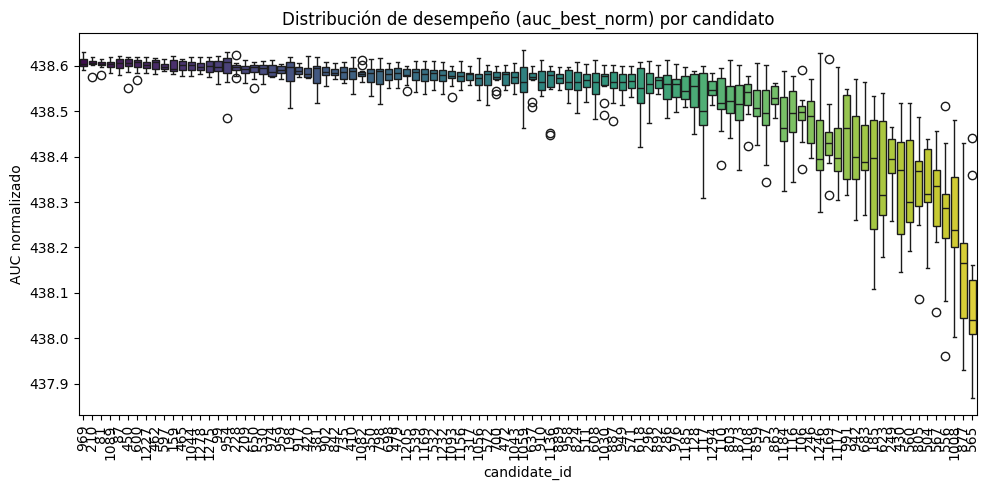

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_finetuning,
    x="candidate_id",
    y="auc_best_norm",
    order=rank_means.index,  # ordenados por rango promedio
    palette="viridis"
)
plt.xticks(rotation=90)
plt.title("Distribución de desempeño (auc_best_norm) por candidato")
plt.ylabel("AUC normalizado")
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd
from scipy.stats import mannwhitneyu
import itertools

# --- Filtramos la métrica de interés ---
metric = "auc_best_norm"

# Agrupamos por candidato
groups = {cid: g[metric].values for cid, g in df_finetuning.groupby("candidate_id")}

# Generamos todas las combinaciones de pares (sin repetición)
pairs = list(itertools.combinations(groups.keys(), 2))

# Ejecutamos Mann-Whitney U para cada par (una-sided: "greater" → c1 > c2)
results = []
for c1, c2 in pairs:
    stat, p = mannwhitneyu(groups[c1], groups[c2], alternative="greater")
    results.append({
        "comparison": f"{c1} > {c2}",
        "n_c1": len(groups[c1]),
        "n_c2": len(groups[c2]),
        "statistic": stat,
        "p_value": p
    })

df_wilcoxon = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)

# Aplicamos Bonferroni para corregir comparaciones múltiples
df_wilcoxon["p_adj_bonferroni"] = df_wilcoxon["p_value"] * len(df_wilcoxon)
df_wilcoxon["significant"] = df_wilcoxon["p_adj_bonferroni"] < 0.05

display(df_wilcoxon.head(10))


,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant
0,228 > 246,11,11,121.0,0.00004,0.197115,False
1,798 > 805,11,11,121.0,0.00004,0.198035,False
2,917 > 942,11,11,121.0,0.00004,0.198035,False
3,798 > 877,11,11,121.0,0.00004,0.198035,False
4,798 > 1008,11,11,121.0,0.00004,0.198035,False
5,228 > 560,11,11,121.0,0.00004,0.198035,False
6,228 > 556,11,11,121.0,0.00004,0.198035,False
7,917 > 991,11,11,121.0,0.00004,0.198035,False
8,228 > 567,11,11,121.0,0.00004,0.198035,False
9,228 > 877,11,11,121.0,0.00004,0.198035,False


In [12]:
df_wilcoxon[df_wilcoxon["significant"]]


,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant


In [13]:
df_wilcoxon.sort_values("p_value", ascending=True)
df_wilcoxon.sort_values("statistic", ascending=False)

,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant
0,228 > 246,11,11,121.0,0.00004,0.197115,False
1,798 > 805,11,11,121.0,0.00004,0.198035,False
2,917 > 942,11,11,121.0,0.00004,0.198035,False
3,798 > 877,11,11,121.0,0.00004,0.198035,False
4,798 > 1008,11,11,121.0,0.00004,0.198035,False
...,...,...,...,...,...,...,...
4945,877 > 917,11,11,0.0,0.99997,4949.849783,False
4946,567 > 798,11,11,0.0,0.99997,4949.849783,False
4947,863 > 917,11,11,0.0,0.99997,4949.849783,False
4948,567 > 917,11,11,0.0,0.99997,4949.849783,False


In [14]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import itertools

# --- Parámetros ---
metric = "auc_best_norm"
alpha = 0.05

# --- Construir matriz seed × candidate ---
pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

# --- Generar combinaciones de pares ---
candidates = pivot.columns.tolist()
pairs = list(itertools.combinations(candidates, 2))

results = []
for c1, c2 in pairs:
    data = pivot[[c1, c2]].dropna()  # elimina seeds faltantes
    if len(data) < 5:
        continue  # descarta pares con pocas observaciones

    # Diferencias por seed
    diff = data[c1] - data[c2]

    # Test una-cola: H1 = c1 > c2
    stat, p = wilcoxon(diff, alternative="greater", zero_method="pratt")

    results.append({
        "c1": c1,
        "c2": c2,
        "comparison": f"{c1} > {c2}",
        "n_seeds": len(data),
        "statistic": stat,
        "p_value": p
    })

df_tests = pd.DataFrame(results)

# --- Corrección Holm (recomendada) ---
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=alpha, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

# --- Corrección Bonferroni (opcional) ---
p_bonf = np.minimum(df_tests["p_value"] * len(df_tests), 1.0)
df_tests["p_bonf"] = p_bonf
df_tests["significant_bonf"] = df_tests["p_bonf"] < alpha

# --- Ordenar por evidencia más fuerte ---
df_tests = df_tests.sort_values("p_holm").reset_index(drop=True)

display(df_tests.head(15))


,c1,c2,comparison,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf
0,57,81,57 > 81,11,0.0,1.000000,1.0,False,1.0,False
1,57,87,57 > 87,11,0.0,1.000000,1.0,False,1.0,False
2,57,99,57 > 99,11,0.0,1.000000,1.0,False,1.0,False
3,57,106,57 > 106,11,39.0,0.318848,1.0,False,1.0,False
4,57,110,57 > 110,11,17.0,0.926270,1.0,False,1.0,False
5,57,116,57 > 116,11,38.5,0.326660,1.0,False,1.0,False
6,57,117,57 > 117,11,29.0,0.649902,1.0,False,1.0,False
7,57,128,57 > 128,11,16.0,0.938477,1.0,False,1.0,False
8,57,159,57 > 159,11,0.0,1.000000,1.0,False,1.0,False
9,57,169,57 > 169,11,52.0,0.050781,1.0,False,1.0,False


In [15]:
df_tests[df_tests["significant_holm"]]


,c1,c2,comparison,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf


In [16]:
# df_tests debe provenir del bloque anterior (Wilcoxon pareado)
# Columnas requeridas: c1, c2, significant_holm

# Inicializamos contadores
candidates = sorted(set(df_tests["c1"]).union(df_tests["c2"]))
summary = pd.DataFrame(index=candidates, columns=["wins", "losses"], data=0)

for _, row in df_tests.iterrows():
    c1, c2 = row["c1"], row["c2"]
    if row["significant_holm"]:  # c1 > c2 con significancia
        summary.loc[c1, "wins"] += 1
        summary.loc[c2, "losses"] += 1

summary["net_wins"] = summary["wins"] - summary["losses"]
summary = summary.sort_values("net_wins", ascending=False)

display(summary)


,wins,losses,net_wins
57,0,0,0
81,0,0,0
87,0,0,0
99,0,0,0
106,0,0,0
...,...,...,...
1232,0,0,0
1246,0,0,0
1275,0,0,0
1278,0,0,0


# Candidatos

In [17]:
import numpy as np
import pandas as pd

# Cálculo del LCB95
g = df_finetuning.groupby("candidate_id")["auc_best_norm"]
mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / np.sqrt(n)

# n=11 → df=10 → t_{0.95,10} ≈ 1.812 (unilateral 95%)
tcrit = 1.812
lcb95 = mean - tcrit * se

# Tabla ordenada únicamente por desempeño robusto
df_lcb = (
    pd.DataFrame({"auc_mean": mean, "auc_std": std, "lcb95": lcb95})
    .sort_values("lcb95", ascending=False)
)

# Elige top K para test pareado
top = 10
short_candidates = df_lcb.head(top).index.tolist()

df_lcb.head(10), short_candidates


(                auc_mean   auc_std       lcb95
 candidate_id                                  
 969           438.606705  0.011830  438.600241
 210           438.604659  0.011351  438.598457
 81            438.603295  0.009050  438.598351
 1089          438.603023  0.010650  438.597204
 1227          438.601659  0.011172  438.595556
 87            438.603568  0.014722  438.595525
 597           438.599750  0.008223  438.595258
 462           438.601795  0.012388  438.595027
 600           438.601932  0.014866  438.593810
 159           438.600568  0.014775  438.592496,
 [969, 210, 81, 1089, 1227, 87, 597, 462, 600, 159])

In [18]:
import itertools
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

metric = "auc_best_norm"
pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

pairs = list(itertools.combinations(short_candidates, 2))
rows = []
for c1, c2 in pairs:
    data = pivot[[c1, c2]].dropna()
    if len(data) < 5:
        continue
    diff = data[c1] - data[c2]  # pareado por seed
    stat, p = wilcoxon(diff, alternative="greater", zero_method="pratt")
    rows.append({"c1": c1, "c2": c2, "n_seeds": len(data), "statistic": stat, "p_value": p})

df_tests = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

# Corrección Holm dentro del shortlist (mucho menos comparaciones)
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=0.05, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

# Bonferroni opcional (clip 1.0)
p_bonf = np.minimum(df_tests["p_value"] * len(df_tests), 1.0)
df_tests["p_bonf"] = p_bonf
df_tests["significant_bonf"] = df_tests["p_bonf"] < 0.05

df_tests = df_tests.sort_values("p_holm").reset_index(drop=True)
df_tests.head(20)


,c1,c2,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf
0,969,597,11,53.0,0.041504,1.0,False,1.0,False
1,969,1227,11,50.5,0.057617,1.0,False,1.0,False
2,969,159,11,48.0,0.095703,1.0,False,1.0,False
3,210,597,11,47.5,0.098633,1.0,False,1.0,False
4,969,462,11,48.0,0.103027,1.0,False,1.0,False
5,81,597,11,46.0,0.126953,1.0,False,1.0,False
6,210,159,11,44.5,0.166504,1.0,False,1.0,False
7,969,1089,11,44.0,0.170898,1.0,False,1.0,False
8,210,81,11,42.5,0.175781,1.0,False,1.0,False
9,1089,597,11,43.5,0.193359,1.0,False,1.0,False


In [19]:
# Resumen de victorias/derrotas usando Holm
cands = sorted(set(df_tests["c1"]).union(df_tests["c2"]))
summary = pd.DataFrame(index=cands, columns=["wins","losses"], data=0)

for _, row in df_tests.iterrows():
    if row["significant_holm"]:
        summary.loc[row["c1"], "wins"]  += 1
        summary.loc[row["c2"], "losses"] += 1

summary["net_wins"] = summary["wins"] - summary["losses"]
summary["win_rate"] = summary["wins"] / (summary["wins"] + summary["losses"] + 1e-9)
summary = summary.sort_values(["win_rate","net_wins","wins"], ascending=[False, False, False])

summary


,wins,losses,net_wins,win_rate
81,0,0,0,0.0
87,0,0,0,0.0
159,0,0,0,0.0
210,0,0,0,0.0
462,0,0,0,0.0
597,0,0,0,0.0
600,0,0,0,0.0
969,0,0,0,0.0
1089,0,0,0,0.0
1227,0,0,0,0.0


In [20]:
import numpy as np
import pandas as pd
from scipy.stats import t

metric = "auc_best_norm"
top = 10  # tamaño del shortlist

g = df_finetuning.groupby("candidate_id")[metric]
mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / np.sqrt(n)

# t crítico unil. 95% por candidato (por si algún n != 11)
tcrit = t.ppf(1 - 0.05, df=(n - 1).clip(lower=1))
lcb95 = mean - tcrit * se
p10   = g.quantile(0.10)

df_lcb = (pd.DataFrame({
    "auc_mean": mean, "auc_std": std, "n": n, "se": se, "lcb95": lcb95, "p10": p10
}).sort_values(["lcb95","p10","auc_mean"], ascending=[False, False, False]))

short_candidates = df_lcb.head(top).index.tolist()
display(df_lcb.head(top))
print("Shortlist:", short_candidates)


,auc_mean,auc_std,n,se,lcb95,p10
candidate_id,,,,,,
969,438.606705,0.011830,11,0.003567,438.600239,438.59375
210,438.604659,0.011351,11,0.003423,438.598456,438.60125
81,438.603295,0.009050,11,0.002729,438.598350,438.59825
1089,438.603023,0.010650,11,0.003211,438.597203,438.58925
1227,438.601659,0.011172,11,0.003368,438.595554,438.58625
87,438.603568,0.014722,11,0.004439,438.595523,438.58025
597,438.599750,0.008223,11,0.002479,438.595256,438.59075
462,438.601795,0.012388,11,0.003735,438.595026,438.58775
600,438.601932,0.014866,11,0.004482,438.593808,438.58475


Shortlist: [969, 210, 81, 1089, 1227, 87, 597, 462, 600, 159]


In [21]:
import itertools
from scipy.stats import wilcoxon

pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

rows = []
for c1, c2 in itertools.combinations(short_candidates, 2):
    data = pivot[[c1, c2]].dropna()
    if len(data) < 5: 
        continue
    d = data[c1] - data[c2]
    stat, p = wilcoxon(d, alternative="greater", zero_method="pratt")
    rows.append({"c1": c1, "c2": c2, "n_seeds": len(d), "statistic": stat, "p_value": p})

df_tests = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

from statsmodels.stats.multitest import multipletests
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=0.05, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

display(df_tests.head(20))

# Tamaño de efecto (Cliff’s delta)
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    gt = sum((xi > yi) for xi in x for yi in y)
    lt = sum((xi < yi) for xi in x for yi in y)
    return (gt - lt) / (len(x) * len(y))

effects = []
for _, r in df_tests.iterrows():
    x = df_finetuning.loc[df_finetuning["candidate_id"]==r["c1"], metric].values
    y = df_finetuning.loc[df_finetuning["candidate_id"]==r["c2"], metric].values
    effects.append({"c1": r["c1"], "c2": r["c2"], "cliffs_delta": cliffs_delta(x, y)})

df_effects = pd.DataFrame(effects).sort_values("cliffs_delta", ascending=False)
display(df_effects.head(20))


,c1,c2,n_seeds,statistic,p_value,p_holm,significant_holm
0,969,597,11,53.0,0.041504,1.0,False
1,969,1227,11,50.5,0.057617,1.0,False
2,969,159,11,48.0,0.095703,1.0,False
3,210,597,11,47.5,0.098633,1.0,False
4,969,462,11,48.0,0.103027,1.0,False
5,81,597,11,46.0,0.126953,1.0,False
6,210,159,11,44.5,0.166504,1.0,False
7,969,1089,11,44.0,0.170898,1.0,False
8,210,81,11,42.5,0.175781,1.0,False
9,1089,597,11,43.5,0.193359,1.0,False


,c1,c2,cliffs_delta
3,210,597,0.438017
0,969,597,0.380165
5,81,597,0.355372
10,87,597,0.280992
2,969,159,0.272727
14,210,1227,0.264463
4,969,462,0.231405
9,1089,597,0.223140
1,969,1227,0.173554
12,210,1089,0.157025


In [22]:
from scipy.stats import wilcoxon

def noninferiority_paired(d, Delta):
    # H0: mu_d <= -Delta  vs  H1: mu_d > -Delta
    # Testea d + Delta > 0 (una cola)
    stat, p = wilcoxon(d + Delta, alternative="greater", zero_method="pratt")
    return p

def nosuperiority_paired(d, Delta):
    # H0: mu_d >=  Delta  vs  H1: mu_d <  Delta
    # Testea -(d - Delta) > 0  => Delta - d > 0  (una cola)
    stat, p = wilcoxon(Delta - d, alternative="greater", zero_method="pratt")
    return p

Delta = 0.010  # margen práctico; ajusta a tu unidad

champion = short_candidates[0]  # top por LCB95
pivot_short = pivot[short_candidates].dropna()
tost_rows = []
for c in short_candidates[1:]:
    d = (pivot_short[champion] - pivot_short[c]).dropna()
    if len(d) < 5:
        continue
    p_noninf = noninferiority_paired(d, Delta)
    p_nosup = nosuperiority_paired(d, Delta)
    # Equivalencia si ambas p < alpha
    tost_rows.append({"champion": champion, "challenger": c,
                      "n_seeds": len(d),
                      "p_noninferior": p_noninf, "p_nosuperior": p_nosup,
                      "equivalent_(TOST)": (p_noninf < 0.05) and (p_nosup < 0.05)})

df_tost = pd.DataFrame(tost_rows).sort_values(["equivalent_(TOST)","p_noninferior","p_nosuperior"],
                                              ascending=[False, True, True])
display(df_tost)


,champion,challenger,n_seeds,p_noninferior,p_nosuperior,equivalent_(TOST)
2,969,1089,11,0.000977,0.041504,True
0,969,210,11,0.001465,0.020020,True
1,969,81,11,0.004883,0.040039,True
3,969,1227,11,0.000977,0.059082,False
5,969,597,11,0.001465,0.318848,False
6,969,462,11,0.004883,0.139160,False
8,969,159,11,0.006348,0.281250,False
4,969,87,11,0.009277,0.100586,False
7,969,600,11,0.009277,0.182617,False


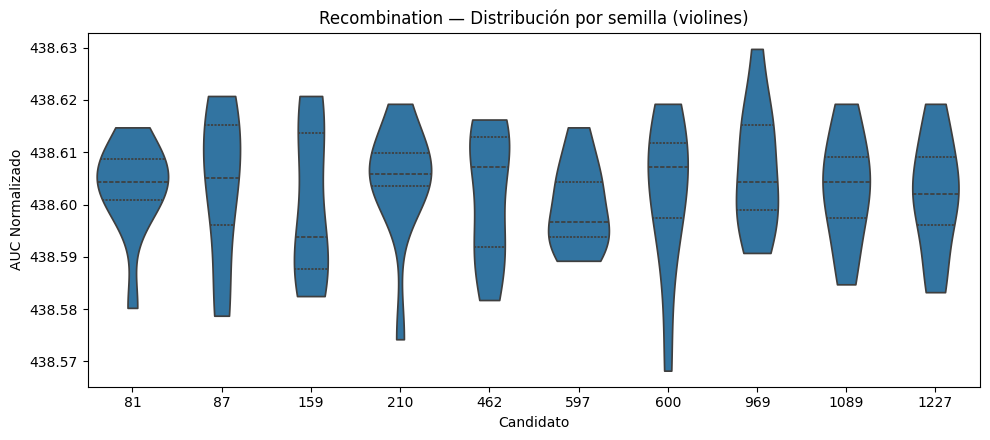

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = [969, 210, 81, 1089, 1227, 87, 597, 462, 600, 159]
subset = df_finetuning[df_finetuning["candidate_id"].isin(top10)]

plt.figure(figsize=(10,4.5))
sns.violinplot(data=subset, x="candidate_id", y="auc_best_norm",
               inner="quartile", cut=0)
plt.title("Recombination — Distribución por semilla (violines)")
plt.xlabel("Candidato")
plt.ylabel("AUC Normalizado")
plt.tight_layout()
plt.show()

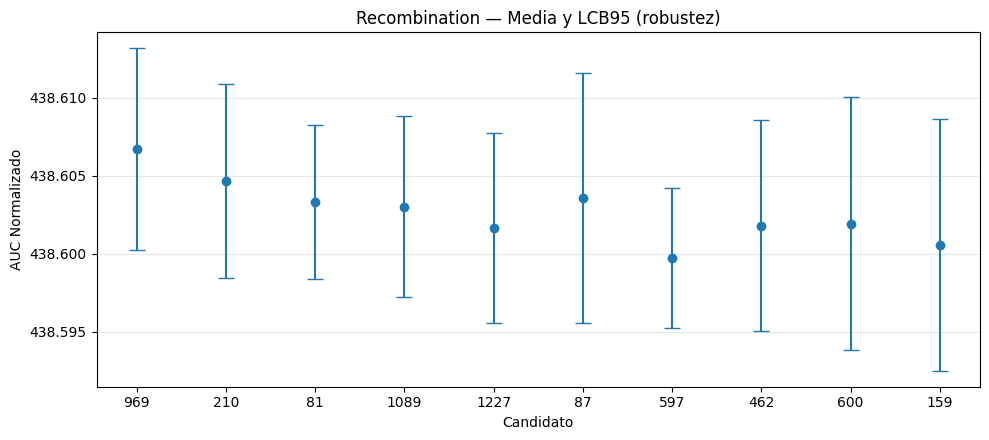

In [29]:
import numpy as np
import matplotlib.pyplot as plt

df_plot = df_lcb.loc[top10, ["auc_mean","lcb95"]].copy()
df_plot["yerr_down"] = df_plot["auc_mean"] - df_plot["lcb95"]

plt.figure(figsize=(10,4.5))
plt.errorbar(df_plot.index.astype(str),
             df_plot["auc_mean"],
             yerr=df_plot["yerr_down"],
             fmt='o', capsize=6)
plt.title("Recombination — Media y LCB95 (robustez)")
plt.xlabel("Candidato")
plt.ylabel("AUC Normalizado")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

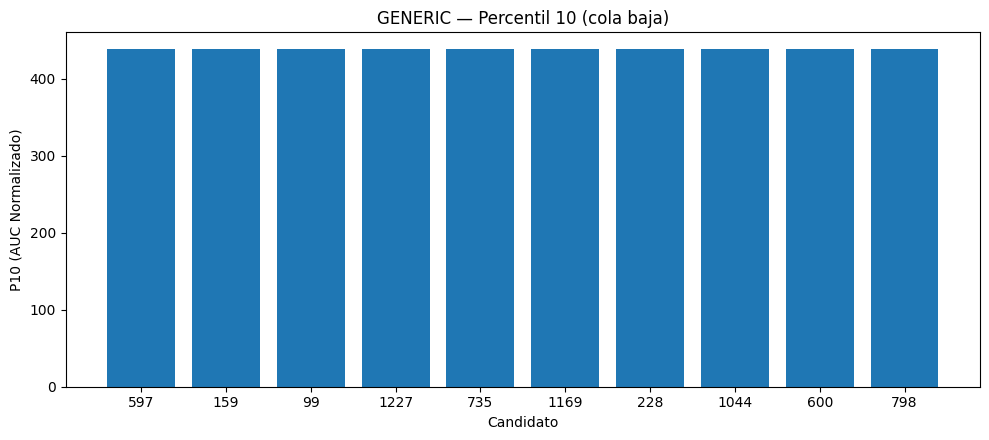

In [25]:
import matplotlib.pyplot as plt

p10_plot = df_lcb.loc[top10, "p10"]

plt.figure(figsize=(10,4.5))
plt.bar(p10_plot.index.astype(str), p10_plot.values)
plt.title("GENERIC — Percentil 10 (cola baja)")
plt.xlabel("Candidato")
plt.ylabel("P10 (AUC Normalizado)")
plt.tight_layout()
plt.show()


In [30]:
winner = 969
report = (
    df_lcb.loc[top10, ["auc_mean","auc_std","n","se","lcb95","p10"]]
      .sort_values("lcb95", ascending=False)
)
print("WINNER (robustez):", winner)
display(report)

WINNER (robustez): 969


,auc_mean,auc_std,n,se,lcb95,p10
candidate_id,,,,,,
969,438.606705,0.011830,11,0.003567,438.600239,438.59375
210,438.604659,0.011351,11,0.003423,438.598456,438.60125
81,438.603295,0.009050,11,0.002729,438.598350,438.59825
1089,438.603023,0.010650,11,0.003211,438.597203,438.58925
1227,438.601659,0.011172,11,0.003368,438.595554,438.58625
87,438.603568,0.014722,11,0.004439,438.595523,438.58025
597,438.599750,0.008223,11,0.002479,438.595256,438.59075
462,438.601795,0.012388,11,0.003735,438.595026,438.58775
600,438.601932,0.014866,11,0.004482,438.593808,438.58475


In [31]:
cid = 969

params_597 = (
    df_finetuning
    .loc[df_finetuning["candidate_id"] == cid, ["sel_mutation", "tail_mutation", "tourn_size"]]
    .iloc[0]
)

params_597

sel_mutation     0.150
tail_mutation    0.035
tourn_size       5.000
Name: 803, dtype: float64